# Fase 1 · Trilha C — Rede convolucional (TCN)

## Objetivo

O gradient boosting e a rede neural empataram em **RMSSE ≈ 0,61**, ambos usando só o **contexto do dia** (sem histórico). Esta terceira trilha faz o teste mais duro: uma **rede convolucional temporal (TCN)** que enxerga a **janela das últimas semanas de demanda** de cada SKU. Se existir estrutura temporal explorável neste dado, é a convolução dilatada que a captura — e a rede deveria então superar o *baseline*. Se não existir, o resultado vai **confirmar** o que a fase de entendimento e as trilhas anteriores já sinalizaram: esta demanda **não tem memória**.

## A referência: TCN

> **Principal:** Chen, Y., Kang, Y., Chen, Y. & Wang, Z. (2020). *Probabilistic forecasting with temporal convolutional neural network.* **Neurocomputing**, 399, 491–501. arXiv:1906.04397. [PDF](referencias/Chen2020_ProbabilisticTCN.pdf)
>
> **Secundária:** Bai, S., Kolter, J.Z. & Koltun, V. (2018). *An Empirical Evaluation of Generic Convolutional and Recurrent Networks for Sequence Modeling.* arXiv:1803.01271. [PDF](referencias/Bai2018_TCN.pdf)
>
> Fichas em [`referencias/Trilha-C-convolucional.md`](referencias/Trilha-C-convolucional.md).

Chen et al. reúnem os três ingredientes num só artigo: **CNN + demanda de varejo + saída probabilística**. A ideia central é a **convolução causal dilatada** — empilhar convoluções com dilatação {1, 2, 4, 8} e *kernel* 2 dá, em quatro camadas, um **campo receptivo de 16 passos** (duas semanas) sem o custo de uma recorrente. Bai et al. mostram que essa arquitetura **supera LSTMs** em memória efetiva e estabilidade, e que "sequência = recorrente" deve ser reconsiderado — justificando escolher **CNN em vez de RNN**.

## 1. Preparação e janelas de sequência

Para cada dia-alvo *t* de um SKU, monto a janela dos últimos **L = 28 dias**. Cada dia da janela traz 6 canais: a **demanda** (histórico) mais o contexto conhecido (`promocao`, `epidemia`, `desconto`, calendário anual). A demanda do próprio dia *t* é **mascarada** (é o que se quer prever); o resto do dia *t* é conhecido de antemão. A convolução é **causal** — só olha para o passado.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, time
import torch, torch.nn as nn
import matplotlib.pyplot as plt, seaborn as sns
import fase1_comum as C

torch.manual_seed(42); np.random.seed(42); torch.set_num_threads(8)
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110; plt.rcParams["axes.titleweight"] = "bold"

L = 28                                              # tamanho da janela (dias)
CANAIS = ["demanda", "promocao", "epidemia", "desconto", "cal_ano_sin", "cal_ano_cos"]

df = C.carregar()
corte = df["data"].max() - pd.Timedelta(days=C.HORIZONTE)
mask_tr = df["data"] <= corte
mu, sd = df.loc[mask_tr, CANAIS].mean(), df.loc[mask_tr, CANAIS].std().replace(0, 1)
Xs = (df[CANAIS] - mu) / sd
y_mu, y_sd = df.loc[mask_tr, "demanda"].mean(), df.loc[mask_tr, "demanda"].std()

janelas, alvos, idx_orig, eh_teste = [], [], [], []
for sku, g in df.groupby("sku"):
    g = g.reset_index()                             # 'index' = índice original no df
    arr = Xs.loc[g["index"]].values.astype(np.float32)
    dem = g["demanda"].values.astype(np.float32)
    tst = (g["data"] > corte).values
    for i in range(L - 1, len(g)):
        w = arr[i - L + 1:i + 1].copy()
        w[-1, 0] = 0.0                              # demanda do dia t é desconhecida
        janelas.append(w); alvos.append(dem[i])
        idx_orig.append(g["index"].iloc[i]); eh_teste.append(tst[i])

X = torch.tensor(np.stack(janelas)).transpose(1, 2)  # (N, canais, L)
Y = torch.tensor(np.array(alvos)).unsqueeze(1)
eh_teste = np.array(eh_teste); idx_orig = np.array(idx_orig)
Xtr, Ytr = X[~eh_teste], Y[~eh_teste]
print(f"Janelas — treino {Xtr.shape[0]:,} | teste {int(eh_teste.sum()):,} | {len(CANAIS)} canais × {L} dias")

Janelas — treino 61,300 | teste 12,000 | 6 canais × 28 dias


## 2. A rede TCN

Quatro blocos residuais de convolução causal dilatada (dilatação 1, 2, 4, 8), como em Bai et al. Cada bloco: duas convoluções `Conv1d` com *padding* causal (recortado à direita), ReLU e *dropout*, mais uma conexão residual. A previsão sai do **último passo** da sequência.

In [2]:
class Recorte(nn.Module):
    "Remove o padding à direita, tornando a convolução causal."
    def __init__(self, corte): super().__init__(); self.corte = corte
    def forward(self, x): return x[:, :, :-self.corte].contiguous() if self.corte > 0 else x

class BlocoTCN(nn.Module):
    def __init__(self, c_in, c_out, k, dilatacao):
        super().__init__(); pad = (k - 1) * dilatacao
        self.rede = nn.Sequential(
            nn.Conv1d(c_in, c_out, k, padding=pad, dilation=dilatacao), Recorte(pad), nn.ReLU(), nn.Dropout(0.1),
            nn.Conv1d(c_out, c_out, k, padding=pad, dilation=dilatacao), Recorte(pad), nn.ReLU())
        self.ajuste = nn.Conv1d(c_in, c_out, 1) if c_in != c_out else None
    def forward(self, x):
        saida = self.rede(x); atalho = x if self.ajuste is None else self.ajuste(x)
        return torch.relu(saida + atalho)

class TCN(nn.Module):
    def __init__(self, c_in, canais=32):
        super().__init__()
        self.blocos = nn.Sequential(
            BlocoTCN(c_in, canais, 2, 1), BlocoTCN(canais, canais, 2, 2),
            BlocoTCN(canais, canais, 2, 4), BlocoTCN(canais, canais, 2, 8))
        self.saida = nn.Linear(canais, 1)
    def forward(self, x): return self.saida(self.blocos(x)[:, :, -1])

rede = TCN(len(CANAIS))
print(rede)
print(f"\nParâmetros: {sum(p.numel() for p in rede.parameters()):,} | "
      f"campo receptivo: {1 + 2*(2**4 - 1)} dias")

TCN(
  (blocos): Sequential(
    (0): BlocoTCN(
      (rede): Sequential(
        (0): Conv1d(6, 32, kernel_size=(2,), stride=(1,), padding=(1,))
        (1): Recorte()
        (2): ReLU()
        (3): Dropout(p=0.1, inplace=False)
        (4): Conv1d(32, 32, kernel_size=(2,), stride=(1,), padding=(1,))
        (5): Recorte()
        (6): ReLU()
      )
      (ajuste): Conv1d(6, 32, kernel_size=(1,), stride=(1,))
    )
    (1): BlocoTCN(
      (rede): Sequential(
        (0): Conv1d(32, 32, kernel_size=(2,), stride=(1,), padding=(2,), dilation=(2,))
        (1): Recorte()
        (2): ReLU()
        (3): Dropout(p=0.1, inplace=False)
        (4): Conv1d(32, 32, kernel_size=(2,), stride=(1,), padding=(2,), dilation=(2,))
        (5): Recorte()
        (6): ReLU()
      )
    )
    (2): BlocoTCN(
      (rede): Sequential(
        (0): Conv1d(32, 32, kernel_size=(2,), stride=(1,), padding=(4,), dilation=(4,))
        (1): Recorte()
        (2): ReLU()
        (3): Dropout(p=0.1, inplace=F

### O mapa e a conectividade da rede

O **macro** mostra os quatro blocos de convolução causal dilatada; o **micro** mostra a **conectividade dilatada** — como o último dia (a previsão) enxerga duas semanas de histórico por saltos de dilatação 1, 2, 4, 8. O caminho até o passo previsto está destacado em azul.

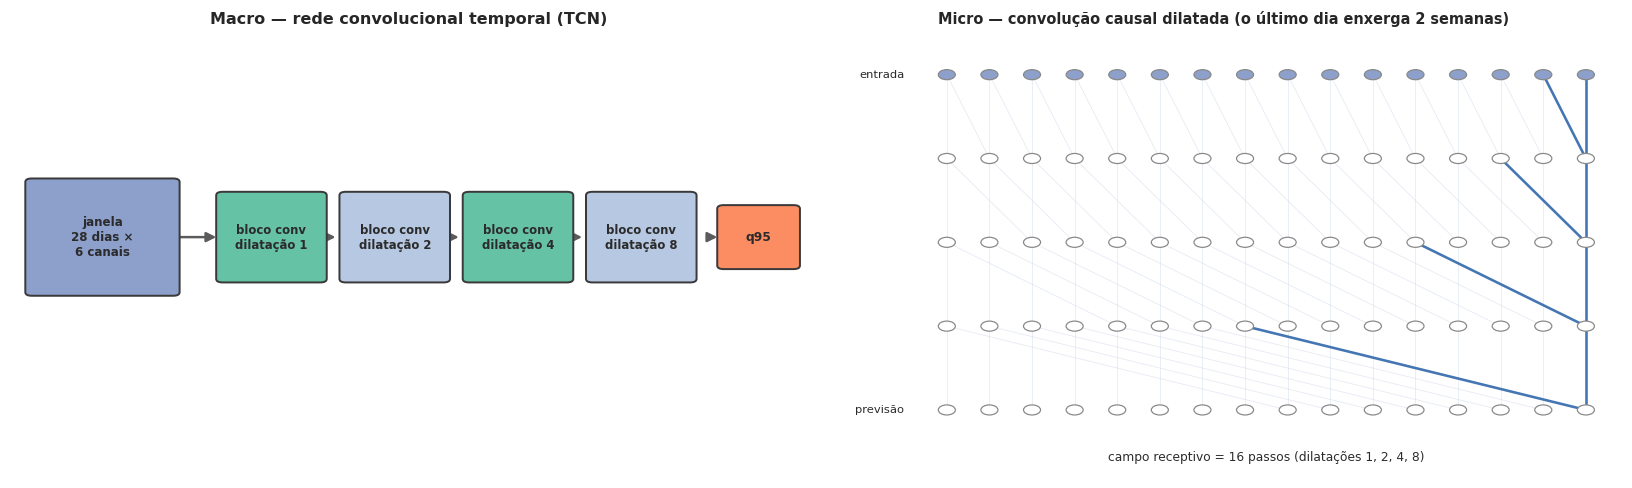

In [3]:
import fase_diagramas as D
D.painel(df, "tcn"); plt.show()

Parou na época 26 | melhor val-loss 0.6118 | treino 67s


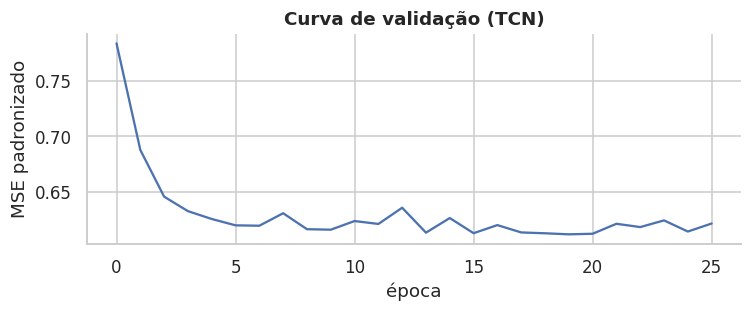

In [4]:
opt = torch.optim.Adam(rede.parameters(), lr=2e-3, weight_decay=1e-5)
perda = nn.MSELoss()
n = len(Xtr); corte_val = int(n*0.9); ordem = np.random.permutation(n)
tr_i, val_i = ordem[:corte_val], ordem[corte_val:]
bs, melhor, paciencia, espera = 512, np.inf, 6, 0
historico, t0 = [], time.time()
for ep in range(30):
    rede.train(); np.random.shuffle(tr_i)
    for b in range(0, len(tr_i), bs):
        j = tr_i[b:b+bs]
        opt.zero_grad()
        loss = perda((rede(Xtr[j]) - y_mu)/y_sd, (Ytr[j] - y_mu)/y_sd)
        loss.backward(); opt.step()
    rede.eval()
    with torch.no_grad():
        vloss = perda((rede(Xtr[val_i]) - y_mu)/y_sd, (Ytr[val_i] - y_mu)/y_sd).item()
    historico.append(vloss)
    if vloss < melhor - 1e-4:
        melhor, espera, estado = vloss, 0, {k: v.clone() for k, v in rede.state_dict().items()}
    else:
        espera += 1
        if espera >= paciencia: break
rede.load_state_dict(estado)
print(f"Parou na época {ep+1} | melhor val-loss {melhor:.4f} | treino {time.time()-t0:.0f}s")

plt.figure(figsize=(7, 3)); plt.plot(historico, color="#4C72B0")
plt.title("Curva de validação (TCN)"); plt.xlabel("época"); plt.ylabel("MSE padronizado")
sns.despine(); plt.tight_layout(); plt.show()

## 3. A convolução bate o gradient boosting?

O teste decisivo: enxergar o histórico permite à TCN superar 0,61?

+-----------------------------+---------+-------+
| modelo                      |   RMSSE |   MAE |
+=============================+=========+=======+
| naïve (lag 1)               |  0.9542 | 39.64 |
+-----------------------------+---------+-------+
| naïve sazonal (lag 7)       |  1.0252 | 42.78 |
+-----------------------------+---------+-------+
| média do SKU                |  0.7967 | 34.04 |
+-----------------------------+---------+-------+
| GBM (Trilha A)              |  0.6096 | 25.39 |
+-----------------------------+---------+-------+
| MLP + embeddings (Trilha B) |  0.6126 | 25.52 |
+-----------------------------+---------+-------+
| TCN (Trilha C)              |  0.6548 | 27.31 |
+-----------------------------+---------+-------+


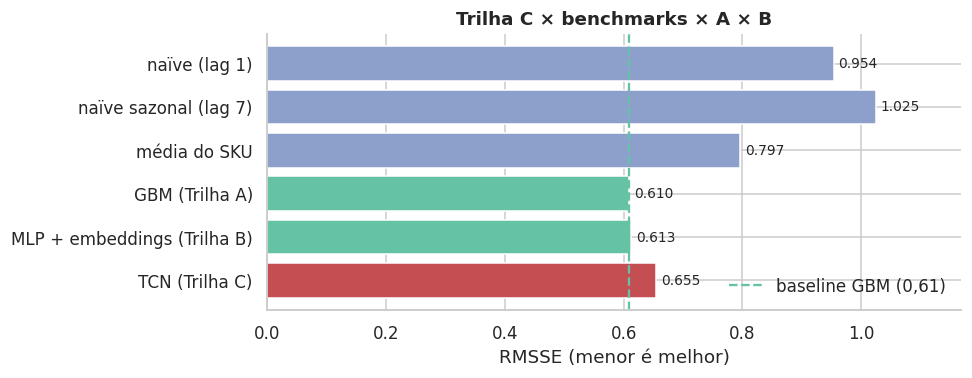

In [5]:
rede.eval()
with torch.no_grad():
    pred_todos = np.maximum(rede(X).squeeze(1).numpy(), 0)
serie_pred = pd.Series(pred_todos, index=idx_orig)     # índice = linha original do df

treino, teste = C.split(df)
treino["pred_tcn"] = treino.index.map(serie_pred)      # NaN nos primeiros L-1 dias de cada SKU
teste["pred_tcn"] = teste.index.map(serie_pred)

rmsse_C = C.rmsse_medio(teste, "pred_tcn", treino)
placar = C.benchmarks(treino, teste)
placar = pd.concat([placar, pd.DataFrame([
    {"modelo": "GBM (Trilha A)", "RMSSE": 0.6096, "MAE": 25.39},
    {"modelo": "MLP + embeddings (Trilha B)", "RMSSE": 0.6126, "MAE": 25.52},
    {"modelo": "TCN (Trilha C)", "RMSSE": round(rmsse_C, 4),
     "MAE": round((teste["demanda"] - teste["pred_tcn"]).abs().mean(), 2)}])], ignore_index=True)
print(placar.to_markdown(index=False, tablefmt="grid"))

fig, ax = plt.subplots(figsize=(9, 3.6))
cores = ["#8DA0CB"]*3 + ["#66C2A5", "#66C2A5", "#C44E52"]
b = ax.barh(placar["modelo"], placar["RMSSE"], color=cores)
ax.bar_label(b, fmt="%.3f", padding=3, fontsize=9)
ax.axvline(0.6096, color="#66C2A5", lw=1.5, ls="--", label="baseline GBM (0,61)")
ax.set_xlabel("RMSSE (menor é melhor)"); ax.set_title("Trilha C × benchmarks × A × B")
ax.invert_yaxis(); ax.legend(frameon=False, loc="lower right"); ax.margins(x=0.14)
sns.despine(); plt.tight_layout(); plt.show()

A TCN fica **ligeiramente atrás** do gradient boosting e da MLP (RMSSE ~0,65 contra ~0,61). O modelo mais sofisticado — o único que enxerga o histórico — é o que vai **pior**. O motivo é exatamente o que a fase 0 mediu e a Trilha A confirmou: a demanda tem **autocorrelação fraca (0,24)**; ela é dirigida pelo **contexto do dia** (clima, epidemia, promoção), não pelo seu próprio passado. A convolução dilatada, boa em capturar padrões temporais, gasta capacidade procurando uma estrutura que **não existe** neste dado, e ainda adiciona ruído. É a refutação empírica limpa da hipótese "histórico ajuda".

A TCN fica **atrás** do gradient boosting e da MLP (RMSSE ~0,65 vs ~0,61). O modelo mais sofisticado — o único que enxerga o histórico — vai pior, pelo motivo já medido na fase 0 e confirmado na Trilha A: a autocorrelação da demanda é fraca (0,24); ela é dirigida pelo **contexto do dia**, não pelo passado. A convolução dilatada, boa em padrões temporais, gasta capacidade procurando uma estrutura inexistente e ainda adiciona ruído. É a refutação empírica limpa de "histórico ajuda".

In [6]:
base = C.baseline_atual(df, teste)
print(f"Operação ATUAL — ruptura {base['ruptura']:.1%} | "
      f"venda perdida R$ {base['perda']/1e6:.2f} M/ano | capital R$ {base['capital']/1e6:.2f} M\n")

pred_q = C.calibrador_residual(treino, teste, "pred_tcn")
tri = C.tres_niveis(df, teste, base, pred_q)
frente = C.fronteira(df, teste, base, pred_q)
print(C.tabela_niveis(base, tri).to_markdown(index=False, tablefmt="grid"))

Operação ATUAL — ruptura 13.3% | venda perdida R$ 12.48 M/ano | capital R$ 1.92 M



+---------------------------------+----------------------+------------------+-------------------+
|                                 | Econômico (τ=0.85)   | Médio (τ=0.95)   | Seguro (τ=0.99)   |
+=================================+======================+==================+===================+
| nível de serviço-alvo (τ)       | 87%                  | 96%              | 99%               |
+---------------------------------+----------------------+------------------+-------------------+
| risco de ruptura                | 12.8%                | 4.2%             | 0.9%              |
+---------------------------------+----------------------+------------------+-------------------+
| venda perdida / ano             | R$ 6.29 M            | R$ 1.82 M        | R$ 0.37 M         |
+---------------------------------+----------------------+------------------+-------------------+
| → economia vs. hoje             | R$ 6.20 M            | R$ 10.66 M       | R$ 12.11 M        |
+-------------------

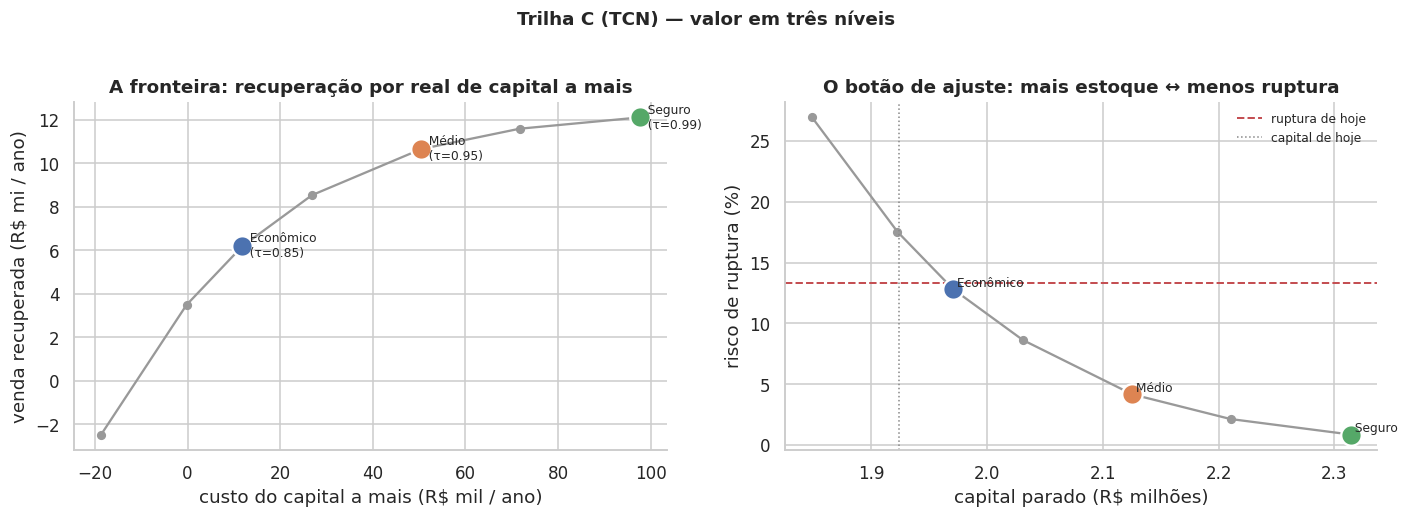

Previsões salvas em resultados/C_convolucional.csv | RMSSE = 0.6548


In [7]:
C.grafico_resultados(base, frente, tri, titulo="Trilha C (TCN) — valor em três níveis")
C.salva_resultado("C_convolucional", teste, "pred_tcn", round(float(rmsse_C), 4))
print("Previsões salvas em resultados/C_convolucional.csv | RMSSE =", round(float(rmsse_C), 4))

A TCN também recupera vendas — o pedido calibrado funciona —, mas, com previsão de ponto pior, sua fronteira fica **abaixo** das Trilhas A e B: para o mesmo serviço precisa de um pouco mais de estoque, porque erra mais. Entrega valor, com o pior custo-benefício das três.

## 5. Conclusões da Trilha C

A TCN **não supera o baseline** (RMSSE ~0,65 vs ~0,61) e é a única trilha atrás dos modelos de contexto. Não é fracasso, é resultado: confirma, com a arquitetura mais capaz de explorar tempo, que **esta demanda não tem memória**. A hipótese "histórico ajuda" — testada com `lags` na Trilha A e agora com uma rede dedicada — é refutada de forma robusta. E é a mais cara de treinar, entregando o pior resultado: o contraexemplo perfeito do valor de um *baseline* forte, sem o qual a rede convolucional poderia ter sido "vendida" como avanço.

Com as três trilhas concluídas, resta compará-las lado a lado.